NeoGuard AI Training Pipeline

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import plotly
import geopandas
import shap
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

Load the dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving NG_2024_DHS_03102026_640_243147.ZIP to NG_2024_DHS_03102026_640_243147.ZIP


In [4]:
import os
os.listdir()

['.config', 'NG_2024_DHS_03102026_640_243147.ZIP', 'sample_data']

In [5]:
#unzip the zip file and stored it as dhs_data
import zipfile

zip_path = "NG_2024_DHS_03102026_640_243147.ZIP"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dhs_data")

print("Unzipped successfully")

Unzipped successfully


In [6]:
os.listdir("dhs_data")

['NGBR8BDT']

In [7]:
#open the folder
os.listdir("dhs_data/NGBR8BDT")

['NGBR8BFL.DO',
 'NGBR8BFL.frq',
 'NGBR8BFL.dta',
 'NGBR8BFL.frw',
 'NGBR8BFL.DCT',
 'NGBR8BFL.map']

In [8]:
pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.1 MB/s eta 0:00:00


In [9]:
import pyreadstat

In [10]:
df, meta = pyreadstat.read_dta("dhs_data/NGBR8BDT/NGBR8BFL.dta")
#ensures all variables stay as raw numeric values
df.head()

,caseid,bidx,v000,v001,v002,v003,v004,v005,v006,v007,...,smgy,idx96,s612ba,s612bb,s612bc,s617a,s626ba,s626bb,s626bc,s631a
0,1 2 2,1,NG8,1,2,2,1,491963,1,2024,...,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1 2 2,2,NG8,1,2,2,1,491963,1,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1 2 2,3,NG8,1,2,2,1,491963,1,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1 2 2,4,NG8,1,2,2,1,491963,1,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1 2 2,5,NG8,1,2,2,1,491963,1,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.shape

(104557, 1336)

In [12]:
df.columns

Index(['caseid', 'bidx', 'v000', 'v001', 'v002', 'v003', 'v004', 'v005',
       'v006', 'v007',
       ...
       'smgy', 'idx96', 's612ba', 's612bb', 's612bc', 's617a', 's626ba',
       's626bb', 's626bc', 's631a'],
      dtype='object', length=1336)

In [13]:
meta.column_labels

['case identification',
 'birth column number',
 'country code and phase',
 'cluster number',
 'household number',
 "respondent's line number",
 'ultimate area unit',
 "women's individual sample weight (6 decimals)",
 'month of interview',
 'year of interview',
 'date of interview (cmc)',
 'date of interview century day code (cdc)',
 "respondent's month of birth",
 "respondent's year of birth",
 'date of birth (cmc)',
 "respondent's current age",
 'age in 5-year groups',
 'completeness of age information',
 'result of individual interview',
 'day of interview',
 'cmc start of calendar',
 'row of month of interview',
 'length of calendar',
 'number of calendar columns',
 'ever-married sample',
 'primary sampling unit',
 'sample strata for sampling errors',
 'stratification used in sample design',
 'zone (code are as per sample frame)',
 'type of place of residence',
 'na - de facto place of residence',
 'number of visits',
 'interviewer identification',
 'na - keyer identification',
 'f

In [14]:
meta.value_labels

{'V013': {1: '15-19',
  2: '20-24',
  3: '25-29',
  4: '30-34',
  5: '35-39',
  6: '40-44',
  7: '45-49'},
 'V014': {1: 'month and year - information complete',
  2: 'month and age - year imputed',
  3: 'year and age - month imputed',
  4: 'year and age - year ignored',
  5: 'year - age/month imputed',
  6: 'age - year/month imputed',
  7: 'month - age/year imputed',
  8: 'none - all imputed'},
 'V015': {1: 'completed',
  2: 'not at home',
  3: 'postponed',
  4: 'refused',
  5: 'partially completed',
  6: 'respondent incapacitated',
  7: 'other'},
 'V018': {0: 'no calendar'},
 'V019': {0: 'no calendar'},
 'V019A': {0: 'no calendar'},
 'V020': {0: 'all woman sample', 1: 'ever married sample'},
 'V022': {1: 'sokoto urban',
  2: 'sokoto rural',
  3: 'zamfara urban',
  4: 'zamfara rural',
  5: 'katsina urban',
  6: 'katsina rural',
  7: 'jigawa urban',
  8: 'jigawa rural',
  9: 'yobe urban',
  10: 'yobe rural',
  11: 'borno urban',
  12: 'borno rural',
  13: 'adamawa urban',
  14: 'adamawa

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104557 entries, 0 to 104556
Columns: 1336 entries, caseid to s631a
dtypes: int64(287), object(1049)
memory usage: 1.0+ GB


In [16]:
df.describe

<bound method NDFrame.describe of                  caseid  bidx v000  v001  v002  v003  v004    v005  v006  \
0              1   2  2     1  NG8     1     2     2     1  491963     1   
1              1   2  2     2  NG8     1     2     2     1  491963     1   
2              1   2  2     3  NG8     1     2     2     1  491963     1   
3              1   2  2     4  NG8     1     2     2     1  491963     1   
4              1   2  2     5  NG8     1     2     2     1  491963     1   
...                 ...   ...  ...   ...   ...   ...   ...     ...   ...   
104552      1400  37  2     2  NG8  1400    37     2  1400  507019     2   
104553      1400  37  2     3  NG8  1400    37     2  1400  507019     2   
104554      1400  37  2     4  NG8  1400    37     2  1400  507019     2   
104555      1400  37  2     5  NG8  1400    37     2  1400  507019     2   
104556      1400  37  2     6  NG8  1400    37     2  1400  507019     2   

        v007  ...  smgy  idx96  s612ba  s612bb  s612bc  s617a  s626ba  s626bb  \
0       2024  ...   NaN      1     NaN     NaN     NaN    NaN     NaN     NaN   
1       2024  ...   NaN    NaN     NaN     NaN     NaN    NaN     NaN     NaN   
2       2024  ...   NaN    NaN     NaN     NaN     NaN    NaN     NaN     NaN   
3       2024  ...   NaN    NaN     NaN     NaN     NaN    NaN     NaN     NaN   
4       2024  ...   NaN    NaN     NaN     NaN     NaN    NaN     NaN     NaN   
...      ...  ...   ...    ...     ...     ...     ...    ...     ...     ...   
104552  2024  ...   NaN    NaN     NaN     NaN     NaN    NaN     NaN     NaN   
104553  2024  ...   NaN    NaN     NaN     NaN     NaN    NaN     NaN     NaN   
104554  2024  ...   NaN    NaN     NaN     NaN     NaN    NaN     NaN     NaN   
104555  2024  ...   NaN    NaN     NaN     NaN     NaN    NaN     NaN     NaN   
104556  2024  ...   NaN    NaN     NaN     NaN     NaN    NaN     NaN     NaN   

        s626bc  s631a  
0          NaN    NaN  
1          NaN    NaN  
2          NaN    NaN  
3          NaN    NaN  
4          NaN    NaN  
...        ...    ...  
104552     NaN    NaN  
104553     NaN    NaN  
104554     NaN    NaN  
104555     NaN    NaN  
104556     NaN    NaN  

[104557 rows x 1336 columns]>

In [17]:
#Create the target variable
for col, label in zip(df.columns, meta.column_labels):
  if label is not None:
    if "alive" in label.lower() or "survive" in label.lower() or "dead" in label.lower():
      print(col, label)

b5 child is alive
b19 current age of child in months (months since birth for dead children)


In [18]:
df["neonatal_death"] = df["b5"].apply(lambda x: 0 if x == 1 else 1)
print(df["neonatal_death"].value_counts())

neonatal_death
0    93088
1    11469
Name: count, dtype: int64


In [19]:
# NEONATAL FILTERING

alive_neonates = df[(df["b5"] == 1) & (df["b19"] <= 1)]
dead_neonates = df[(df["b5"] == 0) & (df["b7"] <= 1 )]
df_neonatal = pd.concat([alive_neonates, dead_neonates])
print("Neonatal dataset shape:", df_neonatal.shape)

Neonatal dataset shape: (4713, 1337)


In [20]:
#DEFINE CANDIDATE FEATURES
candidate_features = [

    "v012",   # mother age
    "v149",   # maternal education
    "v140",   # residence
    "v190",   # wealth index

    "b4",     # child sex
    "bord",   # birth order
    "b11",    # birth interval

    "m15",    # place of delivery
    "m14",    # antenatal visits
    "m1",     # tetanus injection

    "b0",     # multiple birth
    "m19"     # birth weight
    "v151"    #sex of household head
    "v155"    #literacy
    "v161"    #cooking fuel type

]

#detect available features
features = [f for f in candidate_features if f in df.columns]

print("Available features:", features)

Available features: ['v012', 'v149', 'v140', 'v190', 'b4', 'bord', 'b11', 'm15', 'm14', 'm1', 'b0']


In [21]:
df_model = df_neonatal[features + ["neonatal_death"]].copy()
print("Model dataset:", df_model.shape)

Model dataset: (4713, 12)


In [22]:
numeric_cols = df_model.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols = [c for c in features if c not in numeric_cols]

In [23]:
#filling missing values
df_model[numeric_cols] = df_model[numeric_cols].fillna(df_model[numeric_cols].median())

for col in categorical_cols:
  df_model[col] = df_model[col].fillna(df_model[col].mode()[0])

print("After filling missing values:", df_model.shape)

After filling missing values: (4713, 12)


/tmp/ipykernel_1824/1106195785.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model[col] = df_model[col].fillna(df_model[col].mode()[0])


In [24]:
print("Model dataset:", df_model.shape)

Model dataset: (4713, 12)


In [25]:
#categorical columns
categorical_cols = df_model.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
  le = LabelEncoder()
  df_model[col] = le.fit_transform(df_model[col])

print("Categorical features encoded")

Categorical features encoded


In [26]:

#  TRAIN/TEST SPLIT DATA

X = df_model.drop("neonatal_death", axis=1)
y = df_model["neonatal_death"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

In [27]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

In [28]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [29]:
import xgboost as xgb

In [30]:
#train XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    use_label_encoder=False,
    random_state=42
)

xgb_model.fit(X_train_res, y_train_res)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:55:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [31]:

#  TRAIN MODEL(RANDOM FOREST)

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("NeoGuard Model training completed.")

NeoGuard Model training completed.


In [32]:
y_prob = model.predict_proba(X_test)[:, 1]

threshold = 0.15
y_pred = (y_prob >= threshold).astype(int)

In [33]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nAUC Score:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[ 42 141]
 [ 11 749]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.23      0.36       183
           1       0.84      0.99      0.91       760

    accuracy                           0.84       943
   macro avg       0.82      0.61      0.63       943
weighted avg       0.83      0.84      0.80       943


AUC Score: 0.9390135174000575


In [34]:
#risk score calculation

df_model["risk_score"] = xgb_model.predict_proba(df_model[features])[:, 1] * 100

print("Risk scores calculated.")

Risk scores calculated.


In [35]:

#  RISK CATEGORIZATION

def risk_category(score):

    if score < 20:
        return "Low Risk"

    elif score < 50:
        return "Moderate Risk"

    else:
        return "High Risk"

df_model["Risk_Category"] = df_model["risk_score"].apply(risk_category)

df_model[["risk_score", "Risk_Category"]].head()

,risk_score,Risk_Category
154,4.425200,Low Risk
454,23.243256,Moderate Risk
556,1.566316,Low Risk
913,14.902570,Low Risk
986,23.234055,Moderate Risk


In [36]:

# CLINICAL RECOMMENDATION


def clinical_action(category):

    if category == "Low Risk":
        return "Routine neonatal monitoring"

    elif category == "Moderate Risk":
        return "Increase monitoring and counseling"

    else:
        return "URGENT referral to neonatal specialist"

df_model["Clinical_Action"] = df_model["Risk_Category"].apply(clinical_action)

print(df_model[["risk_score", "Risk_Category", "Clinical_Action"]].head())

     risk_score  Risk_Category                     Clinical_Action
154    4.425200       Low Risk         Routine neonatal monitoring
454   23.243256  Moderate Risk  Increase monitoring and counseling
556    1.566316       Low Risk         Routine neonatal monitoring
913   14.902570       Low Risk         Routine neonatal monitoring
986   23.234055  Moderate Risk  Increase monitoring and counseling


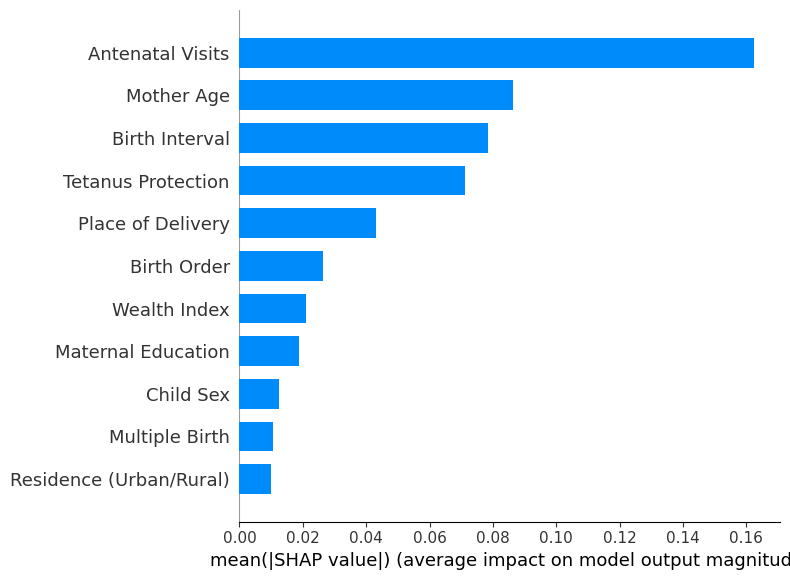

In [40]:


#  SHAP EXPLAINABILITY

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

#map columns to human readable names
feature_name_map = {
    'v012': 'Mother Age',
    'v149': 'Maternal Education',
    'v140': 'Residence (Urban/Rural)',
    'v190': 'Wealth Index',
    'b4': 'Child Sex',
    'bord': 'Birth Order',
    'b11': 'Birth Interval',
    'm15': 'Place of Delivery',
    'm14': 'Antenatal Visits',
    'm1': 'Tetanus Protection',
    'b0': 'Multiple Birth',
    'm19': 'Birth Weight'
}

X_shap = X_test.rename(columns=feature_name_map)


# SHAP Summary Plots

# Bar plot: feature importance across all samples
shap.summary_plot(shap_values[:, :, 1], X_shap, plot_type="bar")




In [41]:

# TOP RISK FACTORS FOR ONE CASE

idx = 0
case_shap = pd.DataFrame({
    'Feature': X_shap.columns,
    'SHAP Value': shap_values[idx, :, 1] # Corrected: direct indexing for NumPy array, selecting positive class
})

# Sort descending by absolute SHAP value
top_factors = case_shap.reindex(case_shap['SHAP Value'].abs().sort_values(ascending=False).index)
print("Top contributing risk factors for this case:\n", top_factors.head(5))


shap.force_plot(explainer.expected_value[1], shap_values[idx, :, 1], X_shap.iloc[idx,:]) # Corrected: select positive class for force_plot

Top contributing risk factors for this case:
               Feature  SHAP Value
0          Mother Age    0.144560
8    Antenatal Visits    0.137943
6      Birth Interval    0.080432
9  Tetanus Protection    0.058368
7   Place of Delivery    0.033619


In [57]:
# SAVE MODEL FOR DEPLOYMENT
joblib.dump(model, "neoguard_model.pkl")





print("NeoGuard model saved.")

NeoGuard model saved.


In [58]:
from google.colab import files
files.download("neoguard_model.pkl")
files.download("neoguard_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

END OF PIPELINE